In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import miceforest as mf

In [2]:
df=pd.read_csv("crop_production.csv")
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [3]:
columns_to_drop = ["District_Name", "Crop_Year"]
df = df.drop(columns=columns_to_drop)
df.head()

,State_Name,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,Whole Year,Cashewnut,720.0,165.0


## Filtering dataset

In [4]:
crops_to_keep = [
    "Rice", "Maize", "Gram", "Rajmash Kholar", "Arhar/Tur", 
    "Moth", "Moong(Green Gram)", "Blackgram", "Masoor", "Pome Granet", 
    "Banana", "Mango", "Grapes", "Water Melon", "Other Fresh Fruits", 
    "Apple", "Orange", "Papaya", "Coconut ", "Cotton(lint)", "Jute", 
    "Coffee","Masoor","Urad"
]
filtered_df = df[df['Crop'].isin(crops_to_keep)]
filtered_df.to_csv("filtered_crop_production.csv", index=False)

In [5]:
data=pd.read_csv("filtered_crop_production.csv")
data.head()

,State_Name,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,Kharif,Rice,102.0,321.0
1,Andaman and Nicobar Islands,Whole Year,Banana,176.0,641.0
2,Andaman and Nicobar Islands,Whole Year,Coconut,18168.0,65100000.0
3,Andaman and Nicobar Islands,Kharif,Rice,83.0,300.0
4,Andaman and Nicobar Islands,Whole Year,Coconut,18190.0,64430000.0


In [6]:
rename_mapping = {
    "Gram": "ChickPea",
    "Rajmash Kholar": "KidneyBeans",
    "Arhar/Tur": "PigeonPeas",
    "Moth": "MothBeans",
    "Moong(Green Gram)": "MungBean",
    "Urad": "Lentil",
    "Masoor": "Lentil",
    "Pome Granet": "Pomegranate",
    "Water Melon": "Watermelon",
    "Cotton(lint)": "Cotton",
    "Other Fresh Fruits":"Muskmelon"
}
data['Crop'] = data['Crop'].replace(rename_mapping)
data.head()

,State_Name,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,Kharif,Rice,102.0,321.0
1,Andaman and Nicobar Islands,Whole Year,Banana,176.0,641.0
2,Andaman and Nicobar Islands,Whole Year,Coconut,18168.0,65100000.0
3,Andaman and Nicobar Islands,Kharif,Rice,83.0,300.0
4,Andaman and Nicobar Islands,Whole Year,Coconut,18190.0,64430000.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82464 entries, 0 to 82463
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State_Name  82464 non-null  object 
 1   Season      82464 non-null  object 
 2   Crop        82464 non-null  object 
 3   Area        82464 non-null  float64
 4   Production  81227 non-null  float64
dtypes: float64(2), object(3)
memory usage: 3.1+ MB


In [8]:
data.isnull().sum()

State_Name       0
Season           0
Crop             0
Area             0
Production    1237
dtype: int64

In [9]:
data_encoded = pd.get_dummies(data, columns=['State_Name', 'Season', 'Crop'])

In [10]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
cols_for_imputation = [col for col in data_encoded.columns if col != 'Production'] + ['Production']
imputer = IterativeImputer(random_state=0)
data_imputed = imputer.fit_transform(data_encoded[cols_for_imputation])
data_imputed = pd.DataFrame(data_imputed, columns=cols_for_imputation)

In [11]:
data['Production'] = data_imputed['Production']

In [12]:
data.to_csv('filtered_crop_production_imputed.csv', index=False)

In [13]:
data.count()

State_Name    82464
Season        82464
Crop          82464
Area          82464
Production    82464
dtype: int64

In [14]:
data.dtypes

State_Name     object
Season         object
Crop           object
Area          float64
Production    float64
dtype: object

In [15]:
data.shape

(82464, 5)

In [16]:
data.columns

Index(['State_Name', 'Season', 'Crop', 'Area', 'Production'], dtype='object')

In [17]:
data.describe()

,Area,Production
count,82464.000000,8.246400e+04
mean,16786.380313,1.622741e+06
std,42380.853467,2.922137e+07
min,0.500000,0.000000e+00
25%,160.000000,1.600000e+02
50%,1400.000000,1.731500e+03
75%,10307.000000,1.800000e+04
max,687000.000000,1.250800e+09


In [18]:
data.Crop.unique()

array(['Rice', 'Banana', 'Coconut ', 'Maize', 'MungBean', 'Lentil',
       'PigeonPeas', 'Cotton', 'ChickPea', 'Grapes', 'Mango', 'Orange',
       'Muskmelon', 'Papaya', 'Pomegranate', 'Jute', 'Blackgram',
       'MothBeans', 'Coffee', 'Watermelon', 'KidneyBeans', 'Apple'],
      dtype=object)

In [19]:
data['Crop'].value_counts()

Crop
Rice           15104
Lentil         14074
Maize          13947
MungBean       10318
PigeonPeas      7578
ChickPea        7361
Cotton          4518
Banana          3209
Coconut         1985
Jute            1453
MothBeans        878
Papaya           483
Mango            449
Muskmelon        410
Orange           271
Grapes           129
Blackgram        118
Watermelon        85
Pomegranate       66
KidneyBeans       18
Coffee             6
Apple              4
Name: count, dtype: int64

In [20]:
data.Season.unique()

array(['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ',
       'Summer     ', 'Winter     '], dtype=object)

In [21]:
data['Season'].value_counts()

Season
Kharif         39396
Rabi           19242
Summer          8961
Whole Year      7972
Autumn          3645
Winter          3248
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Label Encoder

In [23]:
label_encoders = {}
categorical_cols = ['State_Name', 'Season', 'Crop']
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # Save encoders for future use

In [24]:
for col, le in label_encoders.items():
    print(f"Encoding for column: {col}")
    for class_, encoded_value in zip(le.classes_, range(len(le.classes_))):
        print(f"{encoded_value}: {class_}")
    print("\n")

Encoding for column: State_Name
0: Andaman and Nicobar Islands
1: Andhra Pradesh
2: Arunachal Pradesh
3: Assam
4: Bihar
5: Chandigarh
6: Chhattisgarh
7: Dadra and Nagar Haveli
8: Goa
9: Gujarat
10: Haryana
11: Himachal Pradesh
12: Jammu and Kashmir 
13: Jharkhand
14: Karnataka
15: Kerala
16: Madhya Pradesh
17: Maharashtra
18: Manipur
19: Meghalaya
20: Mizoram
21: Nagaland
22: Odisha
23: Puducherry
24: Punjab
25: Rajasthan
26: Sikkim
27: Tamil Nadu
28: Telangana 
29: Tripura
30: Uttar Pradesh
31: Uttarakhand
32: West Bengal


Encoding for column: Season
0: Autumn     
1: Kharif     
2: Rabi       
3: Summer     
4: Whole Year 
5: Winter     


Encoding for column: Crop
0: Apple
1: Banana
2: Blackgram
3: ChickPea
4: Coconut 
5: Coffee
6: Cotton
7: Grapes
8: Jute
9: KidneyBeans
10: Lentil
11: Maize
12: Mango
13: MothBeans
14: MungBean
15: Muskmelon
16: Orange
17: Papaya
18: PigeonPeas
19: Pomegranate
20: Rice
21: Watermelon




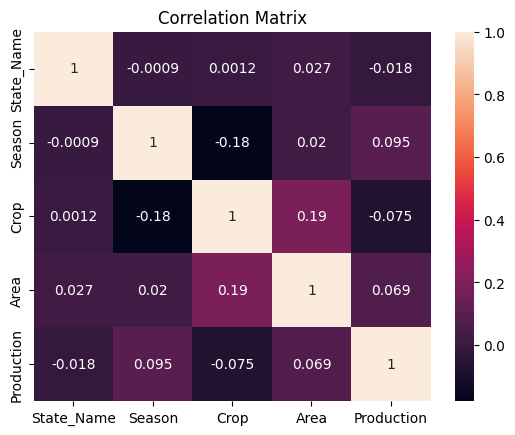

In [25]:
sns.heatmap(data.corr(numeric_only=True), annot =True)
plt.title('Correlation Matrix')
plt.savefig('Yield-corr(BP-4).png')

In [26]:
Q1 = data['Production'].quantile(0.25)
Q3 = data['Production'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [27]:
data['Production'] = np.log1p(data['Production'])
X = data.drop('Production', axis=1)
y = data['Production']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model Building and Evaluation

**Random Forest**<br>
**Decision Tree**<br>
**KNN**<br>
**SVR**<br>
**XGBoost**

In [28]:
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}
results = []
r2_scores = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    std_dev = np.std(residuals)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    r2_scores[name] = r2
    predictions[name] = y_pred   
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2,
        'Std Dev': std_dev
    })
results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2 Score,Std Dev
0,Random Forest,0.523637,1.642623,1.281648,0.856734,1.281646
1,Decision Tree,0.583619,2.112373,1.453401,0.815764,1.453379
2,KNN,0.508204,1.567490,1.251994,0.863287,1.251994
3,SVR,1.362816,4.104182,2.025878,0.642043,2.015769
4,XGBoost,0.511990,1.387992,1.178131,0.878943,1.178125


## Hyper Parameter Tuning with K-fold Cross Validation

In [29]:
from sklearn.model_selection import GridSearchCV, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Random Forest': GridSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        param_grid={
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2']
        },
        cv=kf,
        scoring='r2',
        n_jobs=-1
    ),
    'Decision Tree': GridSearchCV(
        estimator=DecisionTreeRegressor(random_state=42),
        param_grid={
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'criterion': ['squared_error', 'friedman_mse']
        },
        cv=kf,
        scoring='r2',
        n_jobs=-1
    ),
    'KNN': GridSearchCV(
        estimator=KNeighborsRegressor(),
        param_grid={
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        },
        cv=kf,
        scoring='r2',
        n_jobs=-1
    ),
    'SVR': GridSearchCV(
        estimator=SVR(),
        param_grid={
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        },
        cv=kf,
        scoring='r2',
        n_jobs=-1
    ),
    'XGBoost': GridSearchCV(
        estimator=XGBRegressor(random_state=42, n_jobs=-1),
        param_grid={
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0]
        },
        cv=kf,
        scoring='r2',
        verbose=2,
        n_jobs=-1
    )
}

In [30]:
results = []
r2_scores = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)   
    print(f"Best parameters for {name}: {model.best_params_}")    
    residuals = y_test - y_pred
    std_dev = np.std(residuals)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    r2_scores[name] = r2
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2,
        'Std Dev': std_dev
    })
results_df = pd.DataFrame(results)
results_df

Best parameters for Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Best parameters for Decision Tree: {'criterion': 'squared_error', 'max_depth': 15, 'min_samples_split': 10}
Best parameters for KNN: {'n_neighbors': 7, 'weights': 'uniform'}
Best parameters for SVR: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


,Model,MAE,MSE,RMSE,R2 Score,Std Dev
0,Random Forest,0.501908,1.442430,1.201012,0.874195,1.201010
1,Decision Tree,0.549000,1.748846,1.322439,0.847470,1.322439
2,KNN,0.511051,1.522872,1.234047,0.867179,1.234044
3,SVR,1.257123,3.719581,1.928621,0.675587,1.922299
4,XGBoost,0.502780,1.382956,1.175992,0.879382,1.175988


# Model Visualization

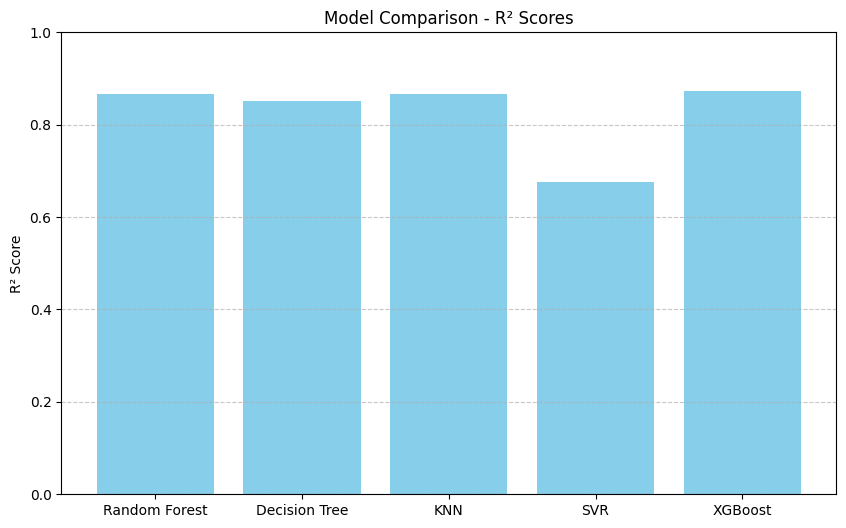

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(r2_scores.keys(), r2_scores.values(), color="skyblue")
plt.ylabel("R² Score")
plt.title("Model Comparison - R² Scores")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('BP-17.png')
plt.show()

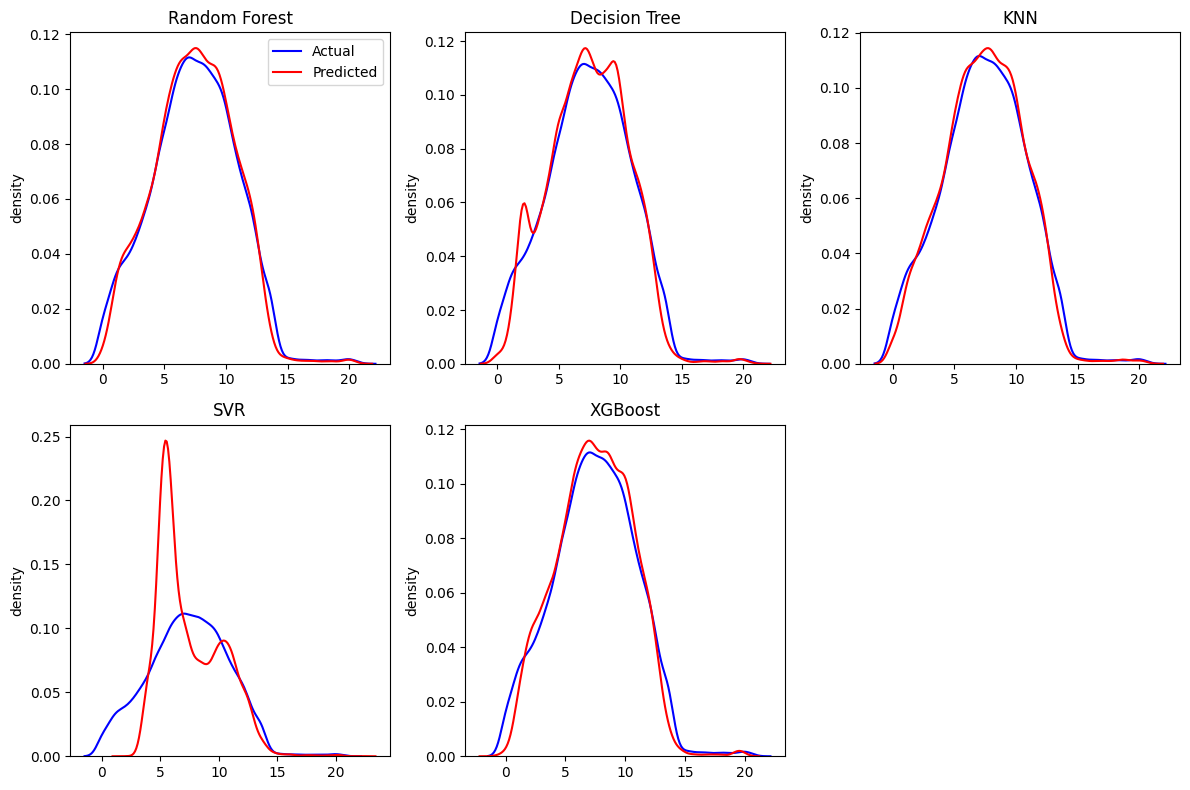

In [34]:
plt.figure(figsize=(12, 8))
for idx, (name, y_pred) in enumerate(predictions.items()):
    plt.subplot(2, 3, idx + 1)
    sns.kdeplot(y_test, color='blue', label='Actual')
    sns.kdeplot(y_pred, color='red', label='Predicted')
    plt.title(name)
    plt.xlabel('')
    plt.ylabel('density')
    if idx == 0:
        plt.legend()
plt.tight_layout()
plt.savefig('BP-18.png')
plt.show()

#### From the above we can say that XGBoost is the best model as it has high R2 score and low error

#### Storing XGBoost model in .pkl file

In [35]:
import pickle
with open('xgboost_model.pkl', 'wb') as file:
    pickle.dump(models['XGBoost'], file)

#### Storing Standard Scaler in .pkl file

In [36]:
import pickle
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Prediction

In [38]:
import joblib
import pandas as pd
model = joblib.load('xgboost_model.pkl') 
scaler = joblib.load('scaler.pkl')

def predict_production():
    print("\nEnter crop details (numeric encoded values):")
    features = [
        int(input("State Name (encoded): ")),
        int(input("Season (encoded): ")),
        int(input("Crop (encoded): ")),
        float(input("Area (hectares): "))
    ]
    input_data = pd.DataFrame([features], columns=[
        'State_Name', 'Season', 'Crop', 'Area'
    ])
    scaled_input = scaler.transform(input_data)
    prediction = model.predict(scaled_input)
    print(f"\nPredicted Production: {prediction[0]:.2f} tonnes")
while True:
    predict_production()
    if input("\nPredict again? (y/n): ").lower() != 'y':
        break


Enter crop details (numeric encoded values):


State Name (encoded):  55
Season (encoded):  3
Crop (encoded):  12
Area (hectares):  230



Predicted Production: 4.73 tonnes



Predict again? (y/n):  n



Enter crop details (numeric encoded values):


State Name (encoded):  22
Season (encoded):  1
Crop (encoded):  2
Area (hectares):  20



Predicted Production: 3.21 tonnes



Predict again? (y/n):  n
